# **CONSUMER CHEESE MATRIX**


# Part 0: Initialisation- import datasets and libraries



In [1]:
# @title Libraries
#mount drive
from google.colab import drive
drive.mount('/content/drive')
#get libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import folium
import numpy as np
from sklearn.cluster import KMeans
import plotly.express as px
import folium
from folium.plugins import MarkerCluster
from google.colab import files
import folium
from folium.plugins import MarkerCluster
import math

Mounted at /content/drive


In [2]:
Raw_sales =pd.read_csv("/content/drive/MyDrive/Teamcheese/sales.csv")

In [3]:
Raw_sales.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Standard Time Dimension,T12M\nFeb.22-Jan.23,T12M\nFeb.22-Jan.23.1,T12M\nFeb.22-Jan.23.2,T12M\nFeb.22-Jan.23.3,T12M\nFeb.22-Jan.23.4,T12M\nFeb.22-Jan.23.5,T12M\nFeb.22-Jan.23.6,T12M\nFeb.22-Jan.23.7,T12M\nFeb.22-Jan.23.8,T12M\nFeb.22-Jan.23.9,T12M\nFeb.22-Jan.23.10,T12M\nFeb.22-Jan.23.11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG,Net weight in KG
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fiscal year/period,002.2023,003.2023,004.2023,005.2023,006.2023,007.2023,008.2023,009.2023,010.2023,011.2023,012.2023,001.2024
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F22,M22,A22,M22,J22,J22,A22,S22,O22,N22,D22,J23
3,Value Fields Grouping,Global Brand (Static),Product Category (Dynamic),Material,NaN,Sold-to (Sales View) L4,NaN,Sold-to (Sales View),KG,KG,KG,KG,KG,KG,KG,KG,KG,KG,KG,KG
4,Net Weight,CASTELLO,Crm Cheese Decorated,22219,Castello pineapple 1kg INT,12133,Grossister.,Delika Food Group A/S,4,4,2,2,NaN,2,4,NaN,5,3,NaN,3


In [4]:
Raw_sales.shape

(7371, 20)

## Rows :7371 , but 1/2 of the top rows are empty..

# Part 1: Initial Data Cleaning- Format rows&columns,remove outliers

In [6]:
months = Raw_sales.iloc[1, 8:].tolist() #select column values after indexnumber 8 in  2nd row ,  save the  month details  in a list  to use it later,
print(months)

['002.2023', '003.2023', '004.2023', '005.2023', '006.2023', '007.2023', '008.2023', '009.2023', '010.2023', '011.2023', '012.2023', '001.2024']


In [7]:
# Create a dictionary to map month numbers to names
month_dict = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# Convert the dates
New_month = [month_dict[int(d[:3])] + d[3:] for d in months]
#Takes the first three characters (which represent the month as a number), converts them to an integer, and uses this to look up the corresponding month name in month_dict.
#Appends the rest of the date string (which is the year) to the month name. The result is a new list of dates in the format MonthYear.

print(New_month)

['Feb.2023', 'Mar.2023', 'Apr.2023', 'May.2023', 'Jun.2023', 'Jul.2023', 'Aug.2023', 'Sep.2023', 'Oct.2023', 'Nov.2023', 'Dec.2023', 'Jan.2024']


In [8]:
df1 = Raw_sales.iloc[4:]# deleting the first 4 rows  and rename the df to df1

In [9]:
# delete the unneccessary columns
columns_to_drop = [0, 3, 5]
df2= df1.drop(df1.columns[columns_to_drop], axis=1)
df2.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 4,Unnamed: 6,Standard Time Dimension,T12M\nFeb.22-Jan.23,T12M\nFeb.22-Jan.23.1,T12M\nFeb.22-Jan.23.2,T12M\nFeb.22-Jan.23.3,T12M\nFeb.22-Jan.23.4,T12M\nFeb.22-Jan.23.5,T12M\nFeb.22-Jan.23.6,T12M\nFeb.22-Jan.23.7,T12M\nFeb.22-Jan.23.8,T12M\nFeb.22-Jan.23.9,T12M\nFeb.22-Jan.23.10,T12M\nFeb.22-Jan.23.11
4,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Grossister.,Delika Food Group A/S,4,4,2,2,NaN,2,4,NaN,5,3,NaN,3
5,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Ishøj,60,119,105,105,120,75,120,75,105,90,52,60
6,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Middelfart,47,177,120,210,135,117,165,150,105,60,67,45
7,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aabenraa,2,2,3,NaN,4,NaN,NaN,2,2,5,NaN,2
8,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Ålborg,NaN,1,2,2,4,NaN,2,NaN,2,4,3,1


In [10]:
# renaming the column by index, renaming the first  5 columns in df2
df2.columns.values[0:5] =["Brand", "Product","Description","ShopType","SoldTo"]

In [11]:
df2.columns.values[5:] =New_month

In [12]:
#Restore the index numbers
df2.reset_index(inplace=True, drop=True)

# Formatted clean df

In [13]:
df2.head()

,Brand,Product,Description,ShopType,SoldTo,Feb.2023,Mar.2023,Apr.2023,May.2023,Jun.2023,Jul.2023,Aug.2023,Sep.2023,Oct.2023,Nov.2023,Dec.2023,Jan.2024
0,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Grossister.,Delika Food Group A/S,4,4,2,2,NaN,2,4,NaN,5,3,NaN,3
1,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Ishøj,60,119,105,105,120,75,120,75,105,90,52,60
2,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Middelfart,47,177,120,210,135,117,165,150,105,60,67,45
3,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aabenraa,2,2,3,NaN,4,NaN,NaN,2,2,5,NaN,2
4,CASTELLO,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Ålborg,NaN,1,2,2,4,NaN,2,NaN,2,4,3,1


# Part 2: Data Exploration

# Part 2.1: Data Exploration- mysterious outlets

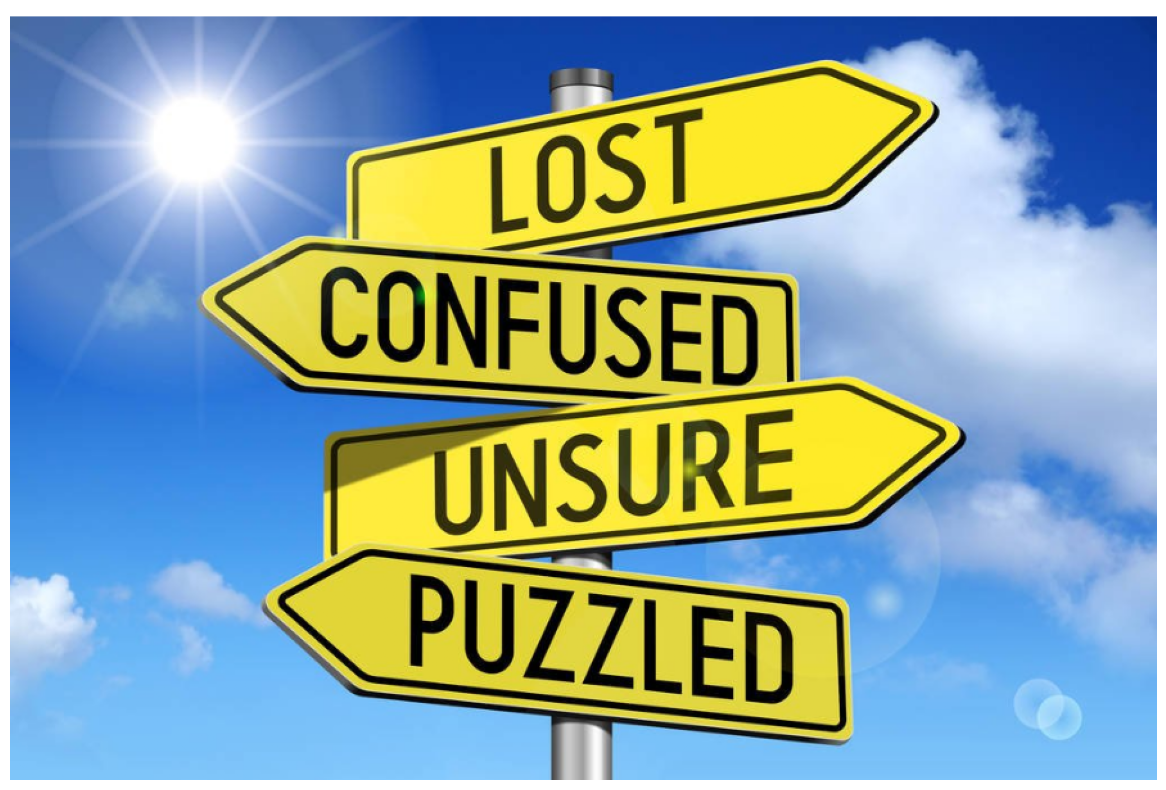

In [ ]:
# @title No City
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image
Nocity = mpimg.imread('/content/drive/MyDrive/Teamcheese/exam image /No city.png')

# Create a figure with the new aspect ratio
plt.figure(figsize=(20, 10))  # Set the figure size to 20 in width and 10 in height

# Display the image
imgplot = plt.imshow(Nocity)

# Hide the axis
plt.axis('off')

# Show the plot without axis values
plt.show()

Geonamescashe provides access to geographical data such as city names, countries, and corresponding latitude and longitude coordinates. It’s useful for applications that need to handle location-based information without making online API callsTo obtain city names, latitude, and longitude data,But it didn't solve the problem .  Then Kelly used  Google Maps Geocoding API to dig out the mysterious locations .

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Teamcheese/sales_cleaned.csv',encoding='utf-8')
df = df.drop(df.columns[0], axis=1)
#latitude and longitude lookup file


In [ ]:
#Convert all sales numbers into integers, strip commas, swap brackets for dash to show negative values, replace blanks with zero
df.iloc[:, 6:18] = df.iloc[:, 6:18].replace({'\,': '', '\(': '-', '\)': ''}, regex=True).apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

In [ ]:
#Convert all sales numbers into integers, strip commas, swap brackets for dash to show negative values, replace blanks with zero
df.iloc[:, 6:18] = df.iloc[:, 6:18].replace({'\,': '', '\(': '-', '\)': ''}, regex=True).apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

In [ ]:
# Make a totals column
total_values = df.loc[:, 'Feb23':'Jan24'].sum(axis=1)
df['Total'] = total_values

In [ ]:
df.head()

,Brand,Product,Description,ShopType,SoldTo,City,Feb23,Mar23,Apr23,May23,Jun23,Jul23,Aug23,Sep23,Oct23,Nov23,Dec23,Jan24,Total
0,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Grossister.,Delika Food Group A/S,Horsens,4,4,2,2,0,2,4,0,5,3,0,3,29
1,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Ishøj,Ishøj,60,119,105,105,120,75,120,75,105,90,52,60,1086
2,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Middelfart,Middelfart,47,177,120,210,135,117,165,150,105,60,67,45,1398
3,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aabenraa,Aabenraa,2,2,3,0,4,0,0,2,2,5,0,2,22
4,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aalborg,Aalborg,0,1,2,2,4,0,2,0,2,4,3,1,21


In [ ]:
geonames_df = pd.read_csv('/content/drive/MyDrive/Teamcheese/Data/Raw/DK.txt', delimiter='\t', encoding='utf-8', header=None)
geonames_columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude',
    'feature class', 'feature code', 'country code', 'cc2', 'admin1 code',
    'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation',
    'dem', 'timezone', 'modification date'
]
geonames_df.columns = geonames_columns
geonames_df = geonames_df[['name','latitude','longitude']]

geonames_df = geonames_df.sort_values('name', ascending=False).drop_duplicates(subset=['name'])
city_coords_dict = geonames_df.set_index('name')[['latitude', 'longitude']].to_dict(orient='index')

# Add latitude and longitude columns using the map function
df['Latitude'] = df['City'].map(lambda x: city_coords_dict.get(x, {}).get('latitude'))
df['Longitude'] = df['City'].map(lambda x: city_coords_dict.get(x, {}).get('longitude'))


In [ ]:
df.head()

,Brand,Product,Description,ShopType,SoldTo,City,Feb23,Mar23,Apr23,May23,...,Jul23,Aug23,Sep23,Oct23,Nov23,Dec23,Jan24,Total,Latitude,Longitude
0,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Grossister.,Delika Food Group A/S,Horsens,4,4,2,2,...,2,4,0,5,3,0,3,29,55.86066,9.85034
1,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Ishøj,Ishøj,60,119,105,105,...,75,120,75,105,90,52,60,1086,55.61543,12.35182
2,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,Dagrofa Foodservice Middelfart,Middelfart,47,177,120,210,...,117,165,150,105,60,67,45,1398,55.50591,9.73054
3,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aabenraa,Aabenraa,2,2,3,0,...,0,0,2,2,5,0,2,22,55.04434,9.41741
4,Castello,Crm Cheese Decorated,Castello pineapple 1kg INT,Foodservice Danmark,DGFS Butik Aalborg,Aalborg,0,1,2,2,...,0,2,0,2,4,3,1,21,57.04800,9.91870


In [ ]:

from google.colab import files

# Convert the DataFrame to a CSV file.
df.to_csv('allsales.csv', index=False)

# Download the file to your local machine.
files.download('allsales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

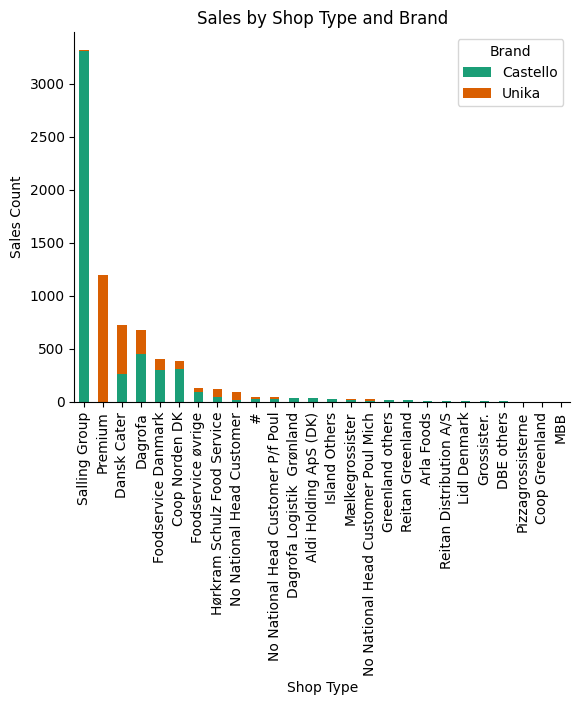

In [ ]:
# @title Part 2.2 Sales by Shop Type and Brand



# Create a frequency table (cross-tabulation) for ShopType and Brand
cross_tab = pd.crosstab(df['ShopType'], df['Brand'])

# Sort the DataFrame by the total sales
cross_tab['total_sales'] = cross_tab.sum(axis=1)
cross_tab_sorted = cross_tab.sort_values(by='total_sales', ascending=False)
cross_tab_sorted.drop(columns='total_sales', inplace=True)

# Plot the stacked bar chart
cross_tab_sorted.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2'))

# Customize plot
plt.title('Sales by Shop Type and Brand')
plt.xlabel('Shop Type')
plt.ylabel('Sales Count')

# Remove spines from the plot
plt.gca().spines[['top', 'right']].set_visible(False)

# Show the plot
plt.show()


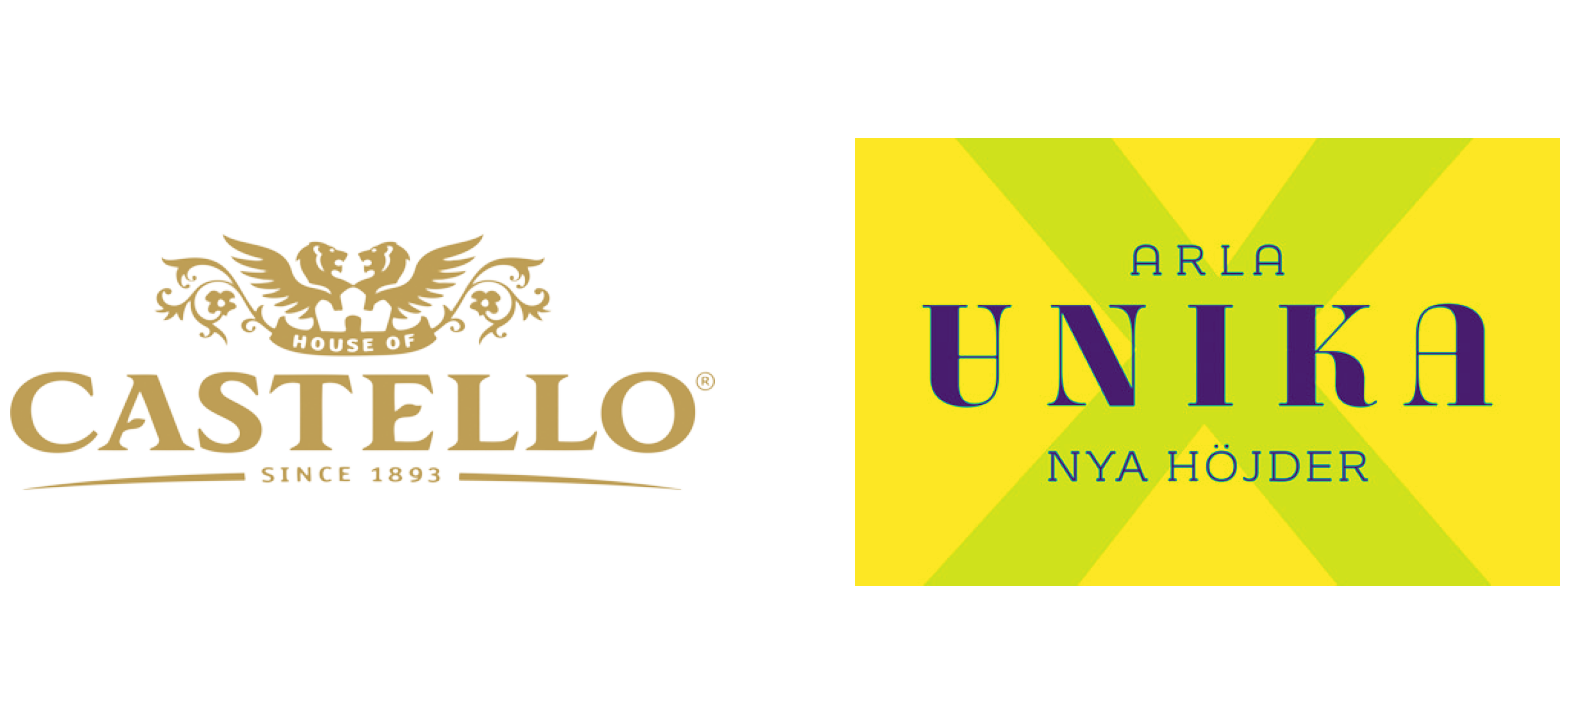

In [ ]:
# @title 2.3 CASTELLO -UNIKA
# Load the images
Castello = mpimg.imread('/content/drive/MyDrive/Teamcheese/exam image /castello.png')
Unika = mpimg.imread("/content/drive/MyDrive/Teamcheese/exam image /unikajpg.jpg")

# Create a figure with 2 subplots
fig, axs = plt.subplots(1, 2, figsize=(20,20))

# Display Castello image on the left subplot
axs[0].imshow(Castello)
#axs[0].set_title('Castello')
axs[0].axis('off')  # Hide axes

# Display Unika image on the right subplot
axs[1].imshow(Unika)
#axs[1].set_title('Unika')
axs[1].axis('off')  # Hide axes

# Show the plot
plt.show()

# 2.4 : Mysterious Hashtag- 19 in unika and  more in Castello

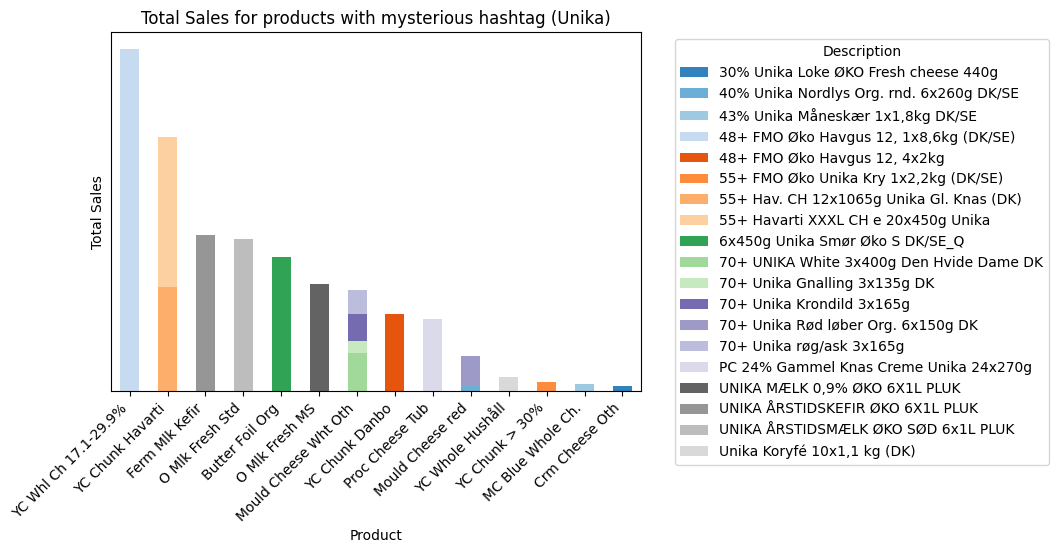

In [ ]:
# @title Unika Hashtag

hashtag_df = df[df['ShopType'] == '#']
unika_hashtag = hashtag_df[hashtag_df['Brand']=="Unika"]

# Group by 'Description' and sum the 'Total' column
grouped = unika_hashtag.groupby(['Description']).agg({'Total': 'sum'}).reset_index()

# Merge the grouped result back with the filtered DataFrame to get 'Brand' and 'Product'
merged = pd.merge(grouped, unika_hashtag[['Description', 'Brand', 'Product']], on='Description').drop_duplicates()

# Reorder the columns
result = merged[['Brand', 'Product', 'Description', 'Total']]
# Sort the result by 'Total' in descending order
result = result.sort_values(by='Total', ascending=False)
result = result.reset_index(drop=True)# Pivot the data to get 'Total' values for each 'Product' and 'Description'
pivot_df = result.pivot(index='Product', columns='Description', values='Total').fillna(0)

# Sum the totals for each product and sort by total sales
total_sales = pivot_df.sum(axis=1).sort_values(ascending=False)
pivot_df = pivot_df.loc[total_sales.index]

# Plot the stacked bar chart
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20c')

plt.xlabel('Product')
plt.ylabel('Total Sales')
# Hide the y-axis values
ax.tick_params(axis='y', which='both', left=False, labelleft=False)

plt.title('Total Sales for products with mysterious hashtag (Unika)')
plt.legend(title='Description', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig('/content/drive/MyDrive/Teamcheese/Visualisations/unika_hashtag_sales.png', dpi=300)
plt.show()

# Part 2.4: Extracting Summary Tables


In [ ]:
# @title  Top selling locations- Unika/Castello
#Isolating Top 20s

# select rows where the value in column 0  contains "Unika"
df_unika= df[df.iloc[:, 0] == 'Unika']
df_castello = df[df.iloc[:,0] == 'Castello']
#df_unika_consumer = df_consumer[df_consumer.iloc[:, 0] == 'Unika']
#df_unika_catering = df_catering[df_catering.iloc[:, 0] == 'Unika']
#you could do the same for "other" if you feel strongly about it
#df_castello_consumer = df_consumer[df_consumer.iloc[:, 0] == 'Castello']
#df_castello_catering = df_catering[df_catering.iloc[:, 0] == 'Castello']

# You can convert any of these dataframes into a csv if you need
#df_FILENAME.to_csv('FILENAME.csv', index=False)
df_castello = df_castello[0:20]
df_unika = df_unika[0:20]



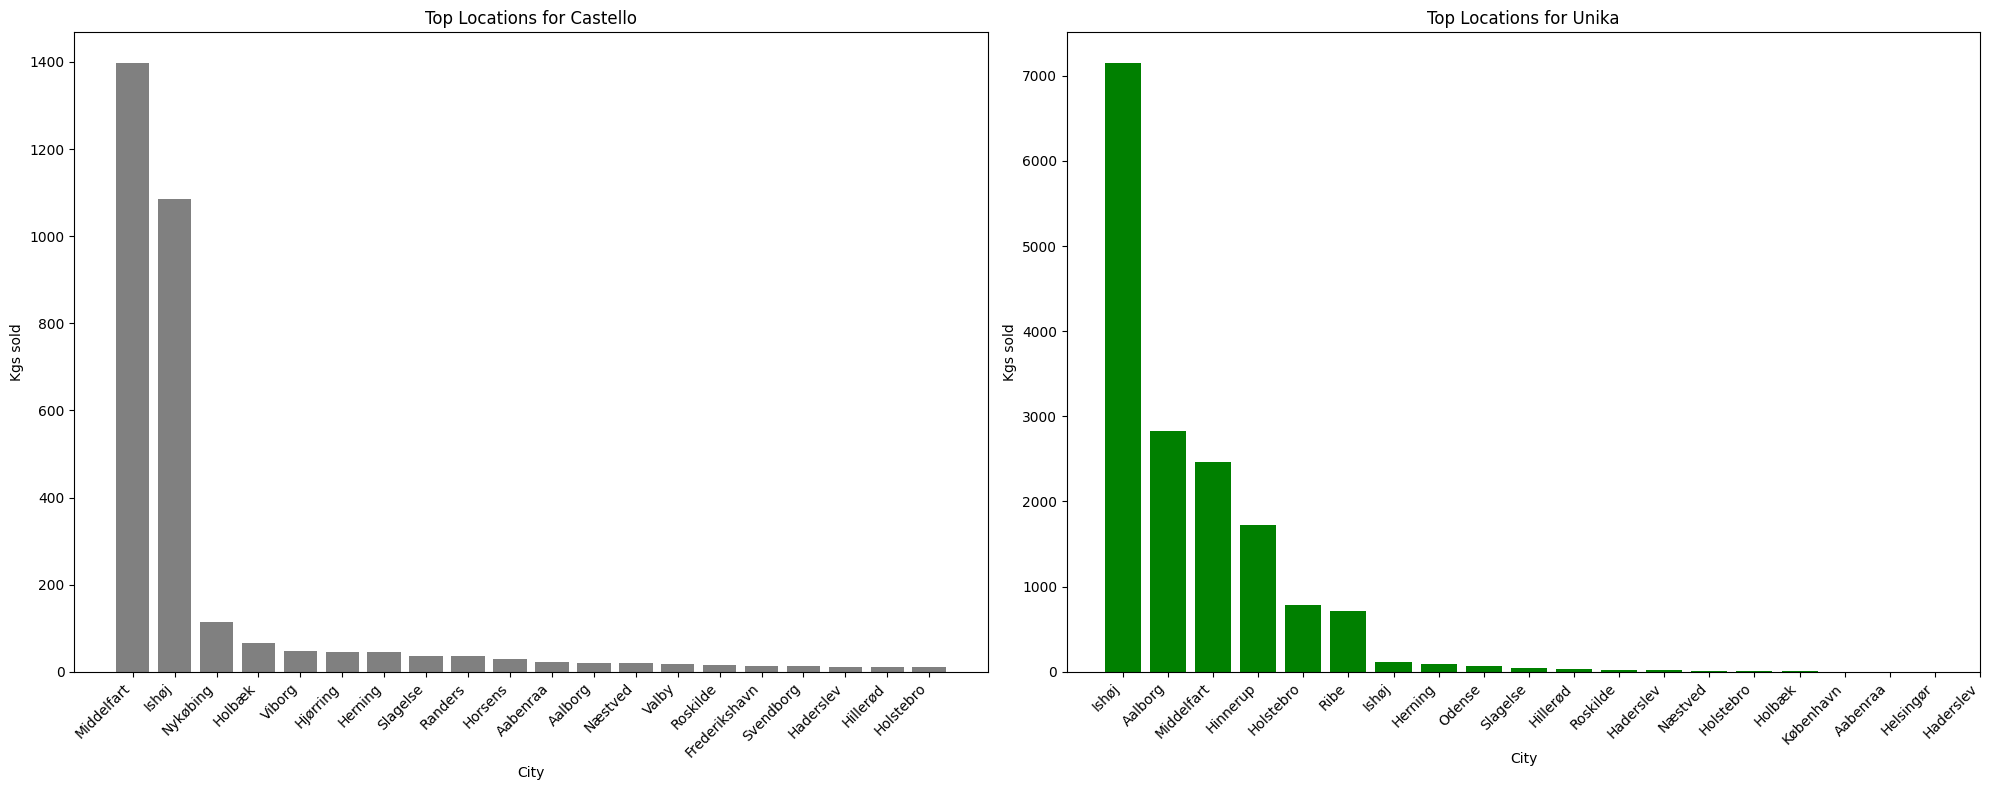

In [ ]:

import matplotlib.pyplot as plt


# Assuming df_castello and df_unika are your dataframes and are already defined

# Sort the dataframes by 'Total' column in descending order
df_castello_sorted = df_castello.sort_values(by='Total', ascending=False)
df_unika_sorted = df_unika.sort_values(by='Total', ascending=False)

# Creating the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))  # Overall figure and two subplots side by side

# First subplot for 'Castello'
ax1.bar(df_castello_sorted['City'], df_castello_sorted['Total'], color='grey')
ax1.set_title('Top Locations for Castello')
ax1.set_xlabel('City')
ax1.set_ylabel('Kgs sold')
ax1.set_xticks(range(len(df_castello_sorted['City'])))
ax1.set_xticklabels(df_castello_sorted['City'], rotation=45, ha="right")

# Second subplot for 'Unika'
ax2.bar(df_unika_sorted['City'], df_unika_sorted['Total'], color='green')
ax2.set_title('Top Locations for Unika')
ax2.set_xlabel('City')
ax2.set_ylabel('Kgs sold')
ax2.set_xticks(range(len(df_unika_sorted['City'])))
ax2.set_xticklabels(df_unika_sorted['City'], rotation=45, ha="right")

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
# function to automate the aggregation by column
def summarize_sales(df, group_by_column, total_column):
    # Group by the specified column and sum the 'Total' column
    total_sum = df.groupby(group_by_column)[total_column].sum().reset_index()

    # Sort the DataFrame by 'Total' in descending order
    total_sum = total_sum.sort_values(total_column, ascending=False).reset_index(drop=True)

    return total_sum

In [ ]:
month_columns = ['Feb23', 'Mar23', 'Apr23', 'May23', 'Jun23', 'Jul23', 'Aug23', 'Sep23',
          'Oct23', 'Nov23', 'Dec23', 'Jan24']
# Summarize sales by Description
#description_sales_summary = summarize_sales(df_unika, 'Description', month_columns)
#print("\nProduct Description Sales Summary:")
#description_sales_summary.head()

# 2.5 : NO City Outlets across Denmarmark

In [ ]:
# Create a map
df = df.loc[df['City'] != 'No city']

# Filter out rows where 'Latitude' or 'Longitude' contains NaNs
df = df.dropna(subset=['Latitude', 'Longitude'])

sales_map = folium.Map(location=[55, 12.5], zoom_start=7)  # Center the map around a relevant location

# Add markers
for idx, row in df.iterrows():
    if row['Total'] < 500:
        continue
    # Define the color based on the brand
    if row['Brand'] == 'Castello':
        color = 'blue'
    elif row['Brand'] == 'Unika':
        color = 'green'
    else:
        color = 'gray'  # Default color for any other brand

    # Create the circle
    folium.Circle(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Total']*0.1,  # Adjust scaling factor as needed
        color=color,
        fill=True,
        fill_color=color,
        tooltip=f'Brand: {row["Brand"]}, City: {row["City"]}, Total Sales: {row["Total"]}'
    ).add_to(sales_map)

# Display the map
sales_map

# Part 3 : In depth Analysis



Adding an extra column so we can explore difference in sales patterns to different segments

In [ ]:
# @title segmentation
import pandas as pd

# Assuming df is already defined and loaded
# Remove whitespace from the 'ShopType' column
df['ShopType'] = df['ShopType'].str.strip()

# Define a dictionary to map values
mapping = {
    'Consumer': ['Dagrofa', 'Reitan Distribution A/S', 'Aldi Holding ApS', 'Coop Norden DK', 'Salling Group', 'Arla Foods'],
    'Catering': ['Grossister.', 'Premium', 'Foodservice Danmark', 'Dansk Cater', 'Foodservice øvrige', 'Hørkram Schulz Food Service', 'MBB', 'Pizzagrossisterne', 'Mælkegrossister'],
}

# Reverse the mapping for easy lookup
reverse_mapping = {}
for key, values in mapping.items():
    for value in values:
        reverse_mapping[value] = key

# Function to get the category from the reverse mapping
def get_category(shop_type):
    return reverse_mapping.get(shop_type, 'Other')

# Create a new column with the assigned values
df['Segment'] = df['ShopType'].apply(get_category)

# Correct the segment for 'Dagrofa Logistik A/S'
df['Segment'] = df.apply(
    lambda row: 'Catering' if row['SoldTo'] == 'Dagrofa Logistik A/S' else row['Segment'],
    axis=1
)

# Reorder columns
cols = df.columns.tolist()
cols.insert(cols.index('ShopType') + 1, cols.pop(cols.index('Segment')))
df = df[cols]

# Separate the DataFrame based on brand
df_unika = df[df['Brand'] == 'Unika']
df_castello = df[df['Brand'] == 'Castello']
# Segment the Unika DataFrame
df_unika_consumer = df_unika[df_unika['Segment'] == 'Consumer'].reset_index(drop=True)
df_unika_catering = df_unika[df_unika['Segment'] == 'Catering'].reset_index(drop=True)
df_unika_other = df_unika[df_unika['Segment'] == 'Other'].reset_index(drop=True)

# Segment the Castello DataFrame
df_castello_consumer = df_castello[df_castello['Segment'] == 'Consumer'].reset_index(drop=True)
df_castello_catering = df_castello[df_castello['Segment'] == 'Catering'].reset_index(drop=True)
df_castello_other = df_castello[df_castello['Segment'] == 'Other'].reset_index(drop=True)

# 3.1 : K means segmentation

In [ ]:
# @title  Unika in different segments
import pandas as pd
from sklearn.cluster import KMeans
import folium
from folium.plugins import MarkerCluster

# Assuming df_unika_consumer, df_unika_catering, df_unika_other are already defined
# Combine all DataFrames
df_combined = pd.concat([df_unika_consumer, df_unika_catering, df_unika_other]).reset_index(drop=True)

# Remove duplicates if any
df_combined = df_combined.drop_duplicates().reset_index(drop=True)

# Drop rows with NaN values
df_combined = df_combined.dropna(subset=['Latitude', 'Longitude'])

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3)
df_combined['cluster'] = kmeans.fit_predict(df_combined[['Latitude', 'Longitude']])

# Create a Folium map
map1 = folium.Map(location=[df_combined['Latitude'].mean(), df_combined['Longitude'].mean()], zoom_start=8)
marker_cluster = MarkerCluster().add_to(map1)

# Add markers to the map
for idx, row in df_combined.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"City: {row['City']}, Cluster: {row['cluster']}"
    ).add_to(marker_cluster)

# Display the map
map1

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


The count of orange Markers (catering or hotel establishments) would indicate the number of such establishments that offer Arla Unika cheese. A higher count in capital region,ishøj .vejle suggest a strong presence in the hospitality sector near tourist attractions.
The count of Yellow Markers (shops) would represent the number of retail outlets selling Arla Unika cheese. Aalborg and Roskilde shows higher count may be  due to the more culltural attractions and the visitors may  prefer to try local products .  There are no outlets in the capital region .
The count of Green Markers show the other type of outlets

# Part 3.2: Melting the data to get a timeseries

In [ ]:
df_unika.head()

,Brand,Product,Description,ShopType,Segment,SoldTo,City,Feb23,Mar23,Apr23,...,Jul23,Aug23,Sep23,Oct23,Nov23,Dec23,Jan24,Total,Latitude,Longitude
5052,Unika,Butter Foil Conv,220g Unika 81 Butter Salted DK/SE,Premium,Catering,Aarøsund Badehotel,Haderslev,0,0,0,...,0,0,0,0,0,0,0,3,55.30222,9.52250
5053,Unika,Butter Foil Conv,220g Unika 81 Butter Salted DK/SE,Premium,Catering,Hotel Sanders,København,0,0,0,...,0,0,0,0,0,5,0,5,55.67110,12.56529
5054,Unika,Butter Foil Org,6x450g Unika Smør Øko S DK/SE_Q,Foodservice Danmark,Catering,Dagrofa Foodservice Ishøj,Ishøj,529,729,729,...,729,972,486,459,486,243,243,7152,55.61543,12.35182
5055,Unika,Butter Foil Org,6x450g Unika Smør Øko S DK/SE_Q,Foodservice Danmark,Catering,Dagrofa Foodservice Middelfart,Middelfart,194,243,194,...,340,292,194,146,97,51,97,2469,55.50591,9.73054
5056,Unika,Butter Foil Org,6x450g Unika Smør Øko S DK/SE_Q,Foodservice Danmark,Catering,DGFS Butik Aabenraa,Aabenraa,0,0,0,...,0,0,0,0,5,0,0,5,55.04434,9.41741


In [ ]:
month_columns = ['Feb23', 'Mar23', 'Apr23', 'May23', 'Jun23', 'Jul23', 'Aug23', 'Sep23',
          'Oct23', 'Nov23', 'Dec23', 'Jan24']

In [ ]:
# Convert columns to numeric, errors='coerce' will turn non-numeric values into NaN
df_unika =df_unika.apply(pd.to_numeric, errors='coerce')

# Now replace NaN values with 0
df_unika = df_unika.fillna(0)



In [ ]:
# Select only the columns representing months from the DataFrame
month_data = df_unika[month_columns]

month_data =month_data.apply(pd.to_numeric, errors='coerce')

# Now replace NaN values with 0
month_data = month_data.fillna(0)
month_data.head()

,Feb23,Mar23,Apr23,May23,Jun23,Jul23,Aug23,Sep23,Oct23,Nov23,Dec23,Jan24
5052,0,0,0,3,0,0,0,0,0,0,0,0
5053,0,0,0,0,0,0,0,0,0,0,5,0
5054,529,729,729,729,818,729,972,486,459,486,243,243
5055,194,243,194,292,329,340,292,194,146,97,51,97
5056,0,0,0,0,0,0,0,0,0,5,0,0


In [ ]:
# Calculate the sum of each column
month_sum= month_data.sum()

# The result is a Series with the column names as the index and their respective sums as the values
print(month_sum)

Feb23    41504
Mar23    60117
Apr23    50765
May23    60378
Jun23    55635
Jul23    55162
Aug23    62825
Sep23    62647
Oct23    45820
Nov23    53614
Dec23    53108
Jan24    45430
dtype: int64


In [ ]:

from google.colab import files

# Convert the DataFrame to a CSV file.
month_sum.to_csv('unikamonth.csv', index=True)

# Download the file to your local machine.
files.download('unikamonth.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


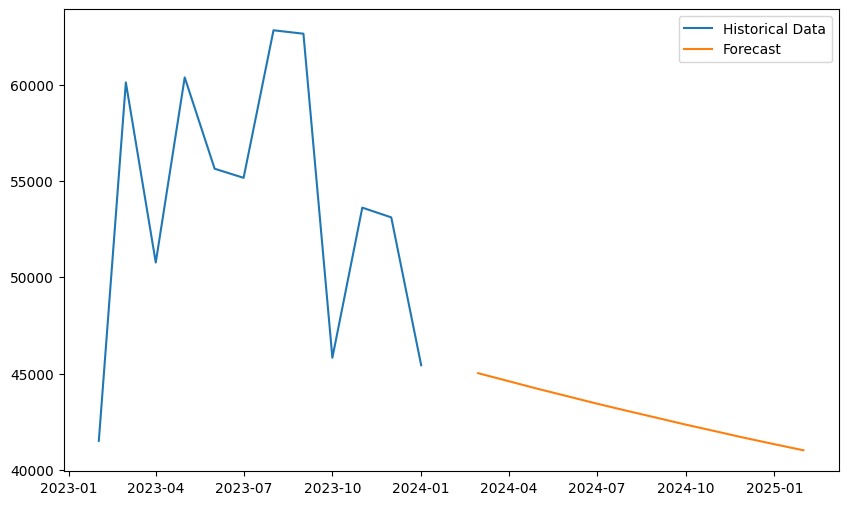

2024-02-01    45015.951905
2024-03-01    44610.882355
2024-04-01    44214.596653
2024-05-01    43826.904322
2024-06-01    43447.619018
2024-07-01    43076.558435
2024-08-01    42713.544223
2024-09-01    42358.401897
2024-10-01    42010.960758
2024-11-01    41671.053806
2024-12-01    41338.517665
2025-01-01    41013.192500
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt

# Step 1: Data Formatting
# Create a DataFrame with your data
data = {
    'Month': ['2023-02', '2023-03', '2023-04', '2023-05', '2023-06',
              '2023-07', '2023-08', '2023-09', '2023-10', '2023-11',
              '2023-12', '2024-01'],
    'Value': [41504, 60117, 50765, 60378, 55635, 55162, 62825, 62647,
              45820, 53614, 53108, 45430]
}
df = pd.DataFrame(data)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Step 2: Time Series Analysis
# Since we only have 12 months of data, we'll skip seasonal decomposition

# Step 3: Model Selection
# We will use ARIMA as an example, but you should explore different models

# Step 4: Model Training
# Fit the ARIMA model (the order (p,d,q) needs to be adjusted based on your data)
model = ARIMA(df['Value'], order=(1, 1, 1))
model_fit = model.fit()

# Step 5: Validation
# With only 12 data points, we don't have enough data to create a separate validation set

# Step 6: Forecasting
# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)

# Step 7: Evaluation
# Without additional data, we cannot perform out-of-sample evaluation

# Step 8: Adjustment
# Adjust model parameters based on the in-sample fit and any available domain knowledge

# Step 9: Deployment
# Deploy the model for actual forecasting

# Step 10: Monitoring
# Monitor the model's performance over time

# Plot the historical data and the forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Value'], label='Historical Data')
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], forecast, label='Forecast')
plt.legend()
plt.show()

# Print the forecast
print(forecast)

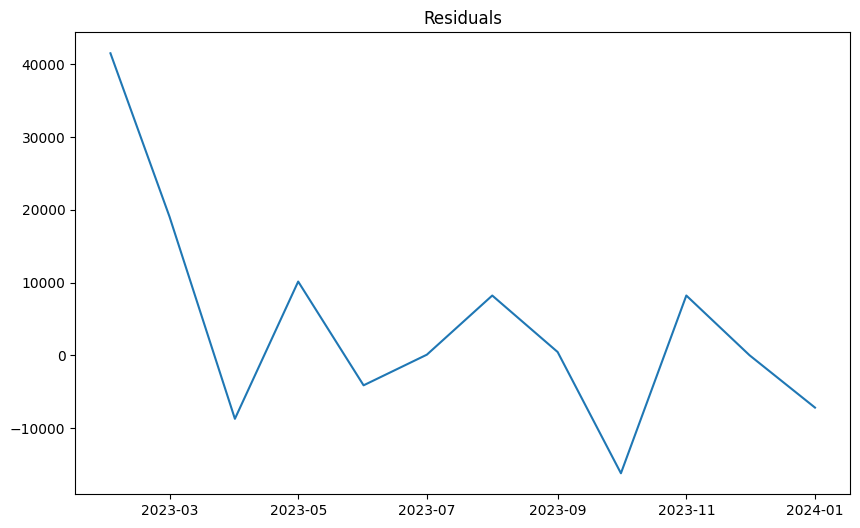

Residuals Mean: 4298.2993933428015


In [ ]:
#Resuídual analysis
residuals = model_fit.resid
plt.figure(figsize=(10, 6))
plt.title('Residuals')
plt.plot(residuals)
plt.show()

print('Residuals Mean:', residuals.mean())

In [ ]:
!pip install plotly

In [ ]:
!pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.8 MB/s eta 0:00:00


# Merge  with web collab

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/merge

/content/drive/MyDrive/Colab Notebooks/merge


In [ ]:
!pip install nbmerge

  Preparing metadata (setup.py) ... done
  Created wheel for nbmerge: filename=nbmerge-0.0.4-py2.py3-none-any.whl size=6394 sha256=3c9adfb1f49aa2b944f6a7d8f778bf88927c73198210d9262f31020bf39fb910
  Stored in directory: /root/.cache/pip/wheels/ab/6a/28/a33b228ce3eda9a7cc2cfd050b24752d09ac76a13733738df5
Successfully built nbmerge
